In [1]:
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_circles, make_gaussian_quantiles
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization

from mlxtend.plotting import plot_decision_regions

I0000 00:00:1789557399.506646   52440 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789557399.567532   52440 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789557402.500170   52440 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


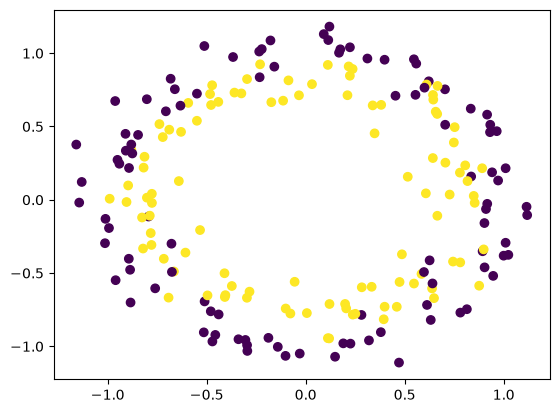

In [2]:
x,y = make_circles(n_samples=200, noise=0.1, random_state=42)

plt.scatter(x[:,0],x[:,1], c=y)

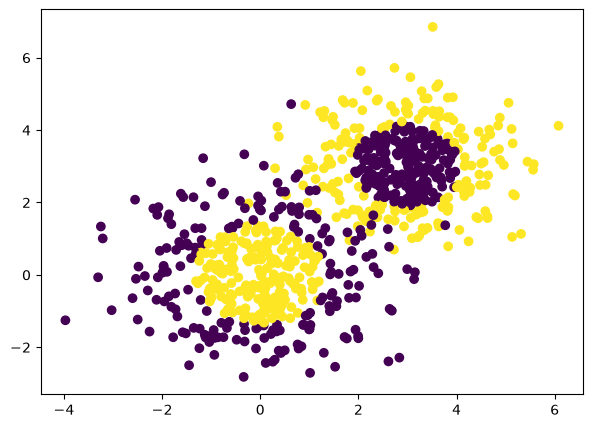

In [3]:

# 1. Generate the first concentric cluster (centered around (3, 3))
X1, y1 = make_gaussian_quantiles(
    mean=(3, 3), cov=1.0, n_samples=400, n_features=2, n_classes=2, random_state=42
)

# 2. Generate the second concentric cluster (centered around (0, 0))
X2, y2 = make_gaussian_quantiles(
    mean=(0, 0), cov=1.5, n_samples=400, n_features=2, n_classes=2, random_state=42
)

# Invert the labels of the second cluster to create the alternating pattern
y2 = 1 - y2

# 3. Combine both datasets
x = np.vstack((X1, X2))
y = np.concatenate((y1, y2))

# 4. Plot the data to match your image
plt.figure(figsize=(7, 5))
plt.scatter(x[:, 0], x[:, 1], c=y, cmap="viridis")
plt.show()

<h3>Without Batch Mormalization</h3>

In [4]:
model1 = Sequential()
model1.add(Dense(10, input_dim=2, activation="relu"))
model1.add(Dense(10,activation="relu"))
model1.add(Dense(1, activation="sigmoid"))
model1.summary()

/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1789557406.519595   52440 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
model1.compile(loss = 'binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history1 = model1.fit(x,y, epochs=200, validation_split=0.2)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5078 - loss: 0.6976 - val_accuracy: 0.5500 - val_loss: 0.6681
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5297 - loss: 0.6855 - val_accuracy: 0.5875 - val_loss: 0.6647
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5453 - loss: 0.6788 - val_accuracy: 0.5875 - val_loss: 0.6620
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5641 - loss: 0.6733 - val_accuracy: 0.6625 - val_loss: 0.6579
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5906 - loss: 0.6683 - val_accuracy: 0.6812 - val_loss: 0.6536
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6187 - loss: 0.6643 - val_accuracy: 0.6562 - val_loss: 0.6502
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6125 - loss: 0.6607 - val_accuracy: 0.6375 - val_loss: 0.6462
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6422 - loss: 0.6564 - val_accuracy: 0.6562 - 

In [6]:
class KerasClassifier:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        y_prob = self.model.predict(X)
        return (y_prob > 0.5).astype(int).flatten()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 874us/step


<Axes: >

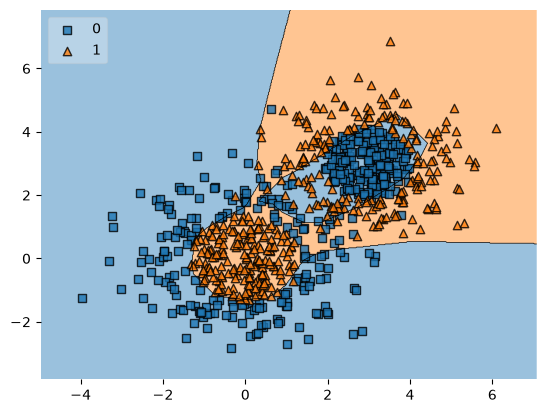

In [7]:
model1 = KerasClassifier(model1)
plot_decision_regions(x, y.flatten(), clf=model1, legend = 2)

<h3>With Batch Mormalization</h3>

In [8]:
model2 = Sequential()
model2.add(Dense(10, input_dim=2, activation="relu"))
model2.add(BatchNormalization())
model2.add(Dense(10,activation="relu"))
model2.add(BatchNormalization())
model2.add(Dense(1, activation="sigmoid"))
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231 (924.00 B)

 Trainable params: 191 (764.00 B)

 Non-trainable params: 40 (160.00 B)

In [9]:
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history2= model2.fit(x,y, epochs=200, validation_split = 0.2)

Epoch 1/200


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5609 - loss: 0.7868 - val_accuracy: 0.4625 - val_loss: 0.7755
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6000 - loss: 0.7144 - val_accuracy: 0.4812 - val_loss: 0.7193
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6234 - loss: 0.6538 - val_accuracy: 0.6750 - val_loss: 0.6655
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6703 - loss: 0.6055 - val_accuracy: 0.7563 - val_loss: 0.6222
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7063 - loss: 0.5742 - val_accuracy: 0.8250 - val_loss: 0.5849
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7609 - loss: 0.5330 - val_accuracy: 0.8438 - val_loss: 0.5570
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7422 - loss: 0.5262 - val_accuracy: 0.8813 - val_loss: 0.5298
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7703 - loss: 0.4943 - val_accuracy: 0.8750 - val_loss: 0.

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 970us/step


<Axes: >

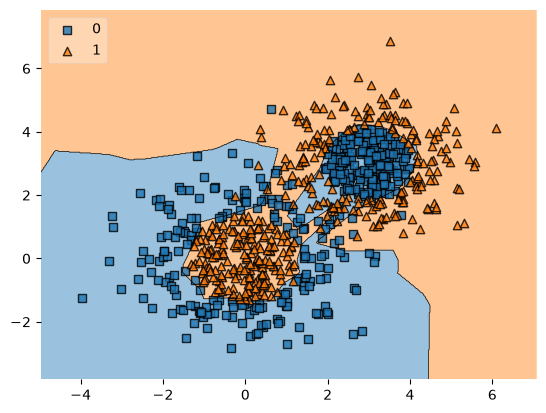

In [10]:
model2 = KerasClassifier(model2)
plot_decision_regions(x, y.flatten(), clf=model2, legend = 2)

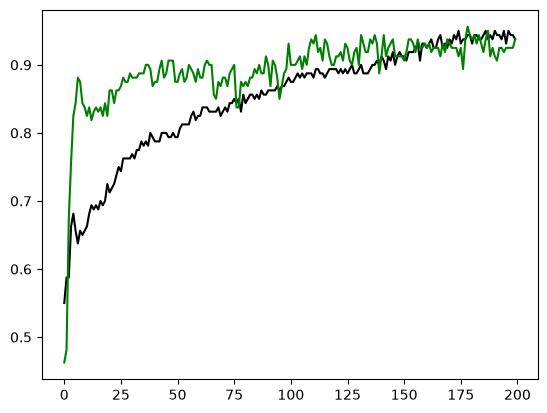

In [11]:
plt.plot(history1.history['val_accuracy'], color='black')
plt.plot(history2.history['val_accuracy'], color='green')